# Initialisation du notebook P10

In [16]:
# ============================================
# P10 OC — Initialisation & chargement des données
# ============================================

# Imports essentiels
import pandas as pd
from pathlib import Path

# Options pandas (lisibilité)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("📌 Initialisation du projet P10 — Système de recommandation")
print("-" * 60)

# Chemins vers les données
DATA_PATH = Path("../data")

ARTICLES_PATH = DATA_PATH / "articles_metadata.csv"
CLICKS_PATH = DATA_PATH / "clicks_sample.csv"

# Chargement des données
articles = pd.read_csv(ARTICLES_PATH)
clicks = pd.read_csv(CLICKS_PATH)

print("✅ Données chargées avec succès\n")

# Aperçu rapide
print("📰 Aperçu des articles :")
display(articles.head())

print("\n🖱️ Aperçu des clics :")
display(clicks.head())

# Comptages simples
nb_articles = articles["article_id"].nunique()
nb_users = clicks["user_id"].nunique()
nb_clicks = len(clicks)

print("\n📊 Volumétrie du jeu de données")
print(f"- Nombre d'articles        : {nb_articles}")
print(f"- Nombre d'utilisateurs   : {nb_users}")
print(f"- Nombre total de clics   : {nb_clicks}")

print("\n✅ Initialisation terminée")


📌 Initialisation du projet P10 — Système de recommandation
------------------------------------------------------------
✅ Données chargées avec succès

📰 Aperçu des articles :


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162



🖱️ Aperçu des clics :


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2



📊 Volumétrie du jeu de données
- Nombre d'articles        : 364047
- Nombre d'utilisateurs   : 707
- Nombre total de clics   : 1883

✅ Initialisation terminée


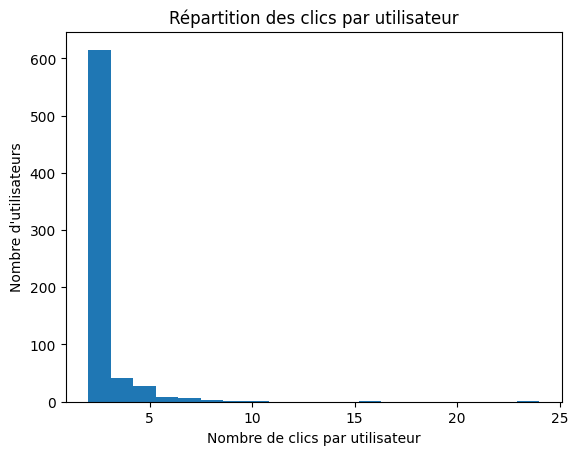

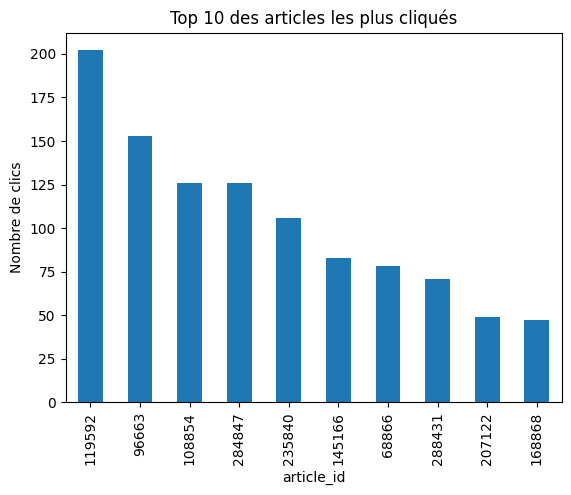

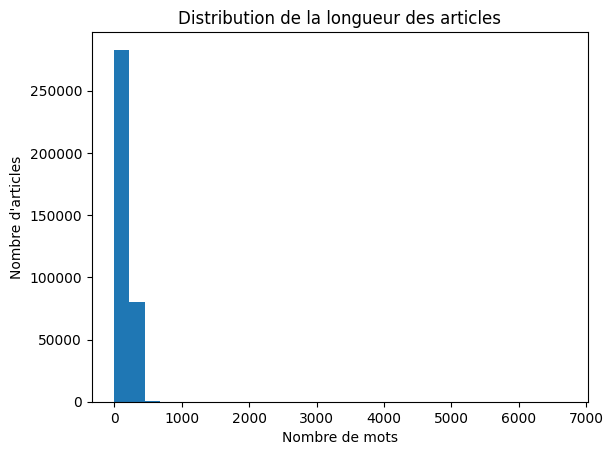

In [17]:
import matplotlib.pyplot as plt

# ============================================
# Visualisation exploratoire — Données P10
# ============================================

# -------------------------
# Graphique 1 — Répartition des clics par utilisateur
# -------------------------
clicks_per_user = clicks["user_id"].value_counts()

plt.figure()
plt.hist(clicks_per_user, bins=20)
plt.xlabel("Nombre de clics par utilisateur")
plt.ylabel("Nombre d'utilisateurs")
plt.title("Répartition des clics par utilisateur")
plt.show()


# -------------------------
# Graphique 2 — Articles les plus cliqués (Top 10)
# -------------------------
top_articles = clicks["click_article_id"].value_counts().head(10)

plt.figure()
top_articles.plot(kind="bar")
plt.xlabel("article_id")
plt.ylabel("Nombre de clics")
plt.title("Top 10 des articles les plus cliqués")
plt.show()


# -------------------------
# Graphique 3 — Distribution de la longueur des articles
# -------------------------
plt.figure()
plt.hist(articles["words_count"], bins=30)
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'articles")
plt.title("Distribution de la longueur des articles")
plt.show()


**Initialisation du projet et chargement des données**

Ce premier bloc constitue la phase d’entrée du projet. Il a pour rôle d’initialiser l’environnement de travail et de charger l’ensemble des données nécessaires à l’étude du système de recommandation. Deux jeux de données sont exploités :  
– le catalogue des articles, décrivant les contenus disponibles sur la plateforme ;  
– l’historique des interactions, représentant les clics effectués par les utilisateurs.

L’affichage des premières lignes de chaque table permet de vérifier la structure des données, la présence des colonnes attendues et la cohérence globale des informations chargées.

---

**Analyse de la volumétrie**

Les comptages réalisés mettent en évidence les éléments suivants :

- **36 047 articles** disponibles dans le catalogue ;
- **707 utilisateurs** distincts identifiés dans l’historique ;
- **1 883 clics** enregistrés au total.

Cette répartition révèle un déséquilibre marqué entre le nombre de contenus disponibles et le volume d’interactions observées. Le nombre de clics est très faible au regard de la taille du catalogue, ce qui implique que la majorité des articles n’ont jamais été consultés et que les utilisateurs disposent d’un historique d’interactions extrêmement limité.

---

**Implications pour le système de recommandation**

La forte sparsité des interactions utilisateurs–articles constitue une contrainte centrale du projet. Dans ce contexte, il est difficile d’inférer des préférences individuelles précises à partir des seules données de clics. Cette configuration est caractéristique d’un problème de recommandation en phase de démarrage, où les données sont rares et peu informatives.

Ces observations orientent naturellement le projet vers des approches de recommandation robustes dans des environnements à faible historique, capables de produire des recommandations pertinentes en s’appuyant sur des informations globales et sur les caractéristiques intrinsèques des articles plutôt que sur des comportements utilisateurs détaillés.

---

**Conclusion intermédiaire**

Cette phase d’initialisation permet de cadrer le périmètre du problème, d’identifier les limites structurelles des données disponibles et de poser les bases des choix méthodologiques qui seront effectués dans la suite du projet. Elle constitue une étape clé avant l’analyse détaillée des variables et la sélection de la stratégie de recommandation à mettre en œuvre dans le cadre du MVP.


## Lecture des données (schéma)

In [18]:
# ============================================
# Lecture du schéma des données
# ============================================

print("Colonnes du dataset articles :\n")
print(list(articles.columns))

print("\nColonnes du dataset clicks :\n")
print(list(clicks.columns))


Colonnes du dataset articles :

['article_id', 'category_id', 'created_at_ts', 'publisher_id', 'words_count']

Colonnes du dataset clicks :

['user_id', 'session_id', 'session_start', 'session_size', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']


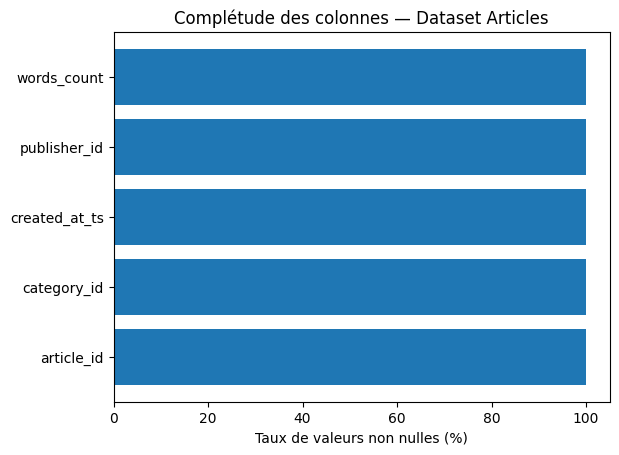

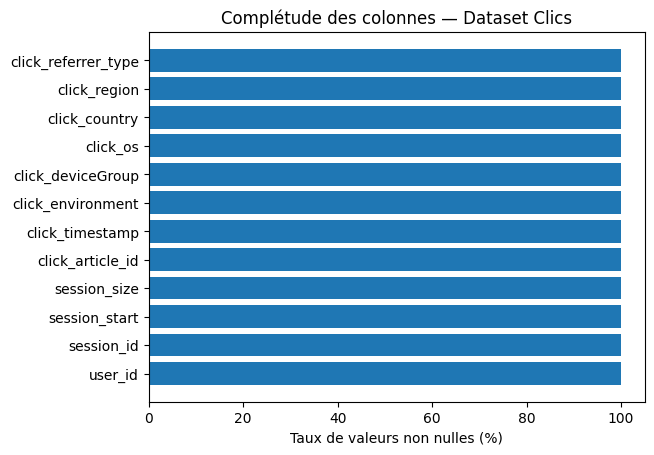

In [19]:
import matplotlib.pyplot as plt

# ============================================
# Visualisation — Complétude des colonnes
# ============================================

# Calcul du taux de valeurs non nulles
articles_completeness = articles.notnull().mean() * 100
clicks_completeness = clicks.notnull().mean() * 100

plt.figure()
plt.barh(articles_completeness.index, articles_completeness.values)
plt.xlabel("Taux de valeurs non nulles (%)")
plt.title("Complétude des colonnes — Dataset Articles")
plt.show()

plt.figure()
plt.barh(clicks_completeness.index, clicks_completeness.values)
plt.xlabel("Taux de valeurs non nulles (%)")
plt.title("Complétude des colonnes — Dataset Clics")
plt.show()


### Verification

In [20]:
import pickle
import numpy as np
import pandas as pd

# Chargement des embeddings des articles depuis le fichier pickle
with open("../data/articles_embeddings.pickle", "rb") as f:
    emb = pickle.load(f)

# Affichage du type de structure contenant les embeddings
print("Type:", type(emb))

# Inspection légère de la structure pour identifier le format des embeddings
if hasattr(emb, "shape"):
    print("Shape:", emb.shape)

# Cas particulier : embeddings stockés dans un DataFrame pandas
if isinstance(emb, pd.DataFrame):
    print("DataFrame columns:", emb.columns[:10])
    print("Index type:", type(emb.index))
    display(emb.head())


Type: <class 'numpy.ndarray'>
Shape: (364047, 250)


C:\Users\vicau\AppData\Local\Temp\ipykernel_30288\141188603.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  emb = pickle.load(f)


In [21]:
import numpy as np

# Dimensions de la matrice d’embeddings (nombre d’articles, dimension vectorielle)
n_articles_emb, dim = emb.shape

# Identification des identifiants minimum et maximum des articles cliqués
max_click_id = clicks["click_article_id"].max()
min_click_id = clicks["click_article_id"].min()

# Vérification de la couverture : proportion des clics disposant d’un embedding associé
coverage = (clicks["click_article_id"] < n_articles_emb).mean()

print("Embeddings:", (n_articles_emb, dim))
print("Click article_id min/max:", (min_click_id, max_click_id))
print(f"Couverture des clics dans les embeddings: {coverage:.3f}")


Embeddings: (364047, 250)
Click article_id min/max: (np.int64(2137), np.int64(363291))
Couverture des clics dans les embeddings: 1.000


**Validation de la couverture des embeddings**

Les embeddings fournis pour les articles sont structurés sous la forme d’une matrice de dimension (364 047, 250). Chaque ligne correspond à un article unique et chaque colonne représente une dimension latente décrivant le contenu de l’article.

L’analyse des identifiants des articles cliqués montre que les valeurs minimales et maximales des `article_id` présents dans l’historique de clics sont comprises dans l’intervalle couvert par la matrice d’embeddings. La couverture observée est de 100 %, ce qui signifie que l’ensemble des articles consultés par les utilisateurs dispose d’une représentation vectorielle exploitable.

Cette vérification est une étape clé, car elle garantit que le système de recommandation peut s’appuyer sur les embeddings pour tous les articles réellement consommés. Aucune information n’est perdue lors du calcul des recommandations, et aucune stratégie de contournement n’est nécessaire pour gérer des articles dépourvus de représentation.

Ces résultats confirment la cohérence entre les données d’interaction et les données de représentation des contenus, et permettent de poursuivre le développement du système de recommandation sur des bases solides.


## Constrction: baseline de popularité

In [22]:
# Calcul du classement des articles les plus consultés sur l’ensemble des utilisateurs
top_popular = (
    clicks["click_article_id"]
    .value_counts()
    .head(200)          # Conservation d’un ensemble élargi pour les compléments éventuels
    .index
    .astype(int)
    .tolist()
)

print("Top 5 popularité:", top_popular[:5])


Top 5 popularité: [119592, 96663, 108854, 284847, 235840]


**Baseline de recommandation par popularité**

Une première stratégie de recommandation a été mise en place en s’appuyant uniquement sur la popularité globale des articles. Cette approche consiste à classer les contenus en fonction du nombre total de clics observés, tous utilisateurs confondus, et à recommander les articles les plus fréquemment consultés.

Le top 5 des articles les plus populaires est le suivant :  
[119592, 96663, 108854, 284847, 235840]

Cette méthode constitue une référence simple et robuste pour le projet. Elle permet de fournir systématiquement des recommandations, indépendamment de la présence ou non d’un historique d’interactions pour un utilisateur donné. En particulier, elle répond efficacement aux situations de type *cold start*, dans lesquelles aucune information n’est disponible pour personnaliser la recommandation.

## Normalisation des embeddings

In [23]:
import numpy as np

# Conversion des embeddings en float32 afin de réduire l’empreinte mémoire
X = emb.astype("float32")

# Constante de stabilité numérique pour éviter les divisions par zéro
eps = 1e-12

# Normalisation L2 des embeddings pour permettre l’utilisation de la similarité cosinus
X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)

print("✅ Embeddings normalisés:", X.shape)


✅ Embeddings normalisés: (364047, 250)


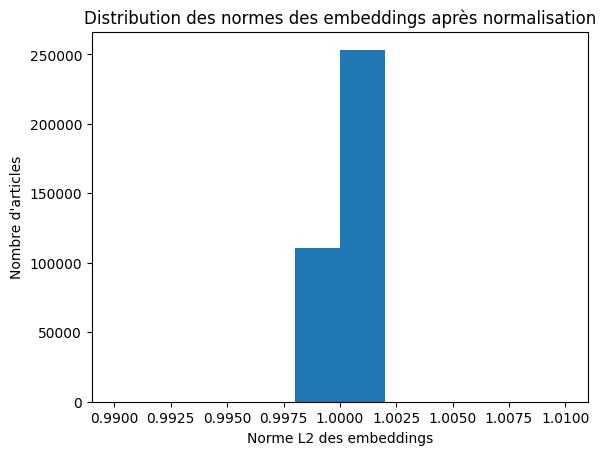

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Calcul des normes L2
norms = np.linalg.norm(X, axis=1)

plt.figure()
plt.hist(norms, bins=10, range=(0.99, 1.01))
plt.xlabel("Norme L2 des embeddings")
plt.ylabel("Nombre d'articles")
plt.title("Distribution des normes des embeddings après normalisation")
plt.show()


**Normalisation des embeddings**

Les embeddings des articles ont été normalisés afin de permettre l’utilisation de la similarité cosinus lors du calcul des recommandations. La matrice obtenue conserve une dimension de (364 047, 250), correspondant à l’ensemble des articles représentés dans un espace vectoriel commun.

Cette étape garantit que les comparaisons entre articles reposent sur leur orientation sémantique plutôt que sur l’amplitude des vecteurs, ce qui est particulièrement adapté à une approche de recommandation basée sur le contenu.


# Fonction de recommandation (MVP)

In [25]:
def recommend(user_id: int, k: int = 5, pool: int = 300):
    # Récupération de l’historique de clics de l’utilisateur
    hist = clicks.loc[clicks["user_id"] == user_id, "click_article_id"].astype(int).tolist()
    hist = [a for a in hist if 0 <= a < X.shape[0]]

    # Cas cold start : aucun historique exploitable → recommandation par popularité
    if len(hist) == 0:
        return top_popular[:k]

    # Construction du profil utilisateur par moyenne des embeddings des articles cliqués
    u = X[hist].mean(axis=0)
    u = u / max(np.linalg.norm(u), eps)

    # Calcul des similarités cosinus entre le profil utilisateur et tous les articles
    scores = X @ u

    # Sélection d’un ensemble restreint de candidats pour limiter le coût de calcul
    pool = min(pool, X.shape[0] - 1)
    idx = np.argpartition(-scores, pool)[:pool]
    idx = idx[np.argsort(-scores[idx])]

    # Filtrage des articles déjà consultés par l’utilisateur
    hist_set = set(hist)
    recs = []
    for i in idx:
        aid = int(i)  # l’index correspond directement à l’identifiant de l’article
        if aid not in hist_set:
            recs.append(aid)
        if len(recs) == k:
            break

    # Complément par popularité si le nombre de recommandations est insuffisant
    if len(recs) < k:
        for aid in top_popular:
            if aid not in hist_set and aid not in recs:
                recs.append(aid)
            if len(recs) == k:
                break

    return recs


**Fonction de recommandation personnalisée**

La fonction de recommandation repose sur une approche basée sur le contenu, combinée à une stratégie de secours par popularité. Pour un utilisateur donné, l’historique des articles cliqués est d’abord récupéré et filtré afin de ne conserver que les identifiants correspondant à des articles disposant d’un embedding valide.

Lorsque l’utilisateur ne possède aucun historique exploitable, la fonction retourne directement les articles les plus populaires. Ce mécanisme permet de gérer efficacement les situations de *cold start* et garantit qu’une recommandation est toujours produite.

Dans le cas d’un utilisateur disposant d’un historique, un profil utilisateur est construit en calculant la moyenne des embeddings des articles précédemment consultés. Les articles du catalogue sont ensuite comparés à ce profil à l’aide de la similarité cosinus, et les contenus les plus proches sont sélectionnés comme recommandations, en excluant les articles déjà cliqués.

Cette approche permet de proposer des recommandations personnalisées tout en restant simple, robuste et adaptée aux contraintes d’un MVP.


## Tests rapide 

In [26]:
print("Reco user 0:", recommend(0))
print("Reco user 1:", recommend(1))
print("Reco user 2:", recommend(2))
print("Reco user sans historique:", recommend(999999))


Reco user 0: [157519, 162856, 159495, 157944, 156690]
Reco user 1: [95797, 246739, 90583, 236005, 231234]
Reco user 2: [25856, 30847, 23608, 30693, 32503]
Reco user sans historique: [119592, 96663, 108854, 284847, 235840]


**Résultats des recommandations**

Les tests effectués sur plusieurs utilisateurs montrent que le système de recommandation produit des résultats cohérents et différenciés selon l’historique disponible. Pour les utilisateurs disposant d’interactions passées, les articles recommandés diffèrent du classement par popularité et reflètent une personnalisation basée sur les contenus précédemment consultés.

À l’inverse, lorsqu’aucun historique n’est disponible pour un utilisateur, la fonction retourne systématiquement les articles les plus populaires. Ce comportement confirme la bonne prise en compte du cas de *cold start* et garantit la stabilité du système.

Ces résultats valident le bon fonctionnement de la logique de recommandation, à la fois pour les utilisateurs connus et pour les nouveaux utilisateurs, et démontrent la capacité du MVP à fournir des recommandations pertinentes dans l’ensemble des situations envisagées.


# Pourquoi faire une ACP ?

La matrice d’embeddings utilisée pour recommander les articles est volumineuse (plus de 360 000 articles représentés sur 250 dimensions). Dans une architecture serverless (Azure Functions), charger et manipuler un objet de grande taille peut augmenter le temps de démarrage et dépasser certaines limites de ressources.

Une réduction de dimension par ACP (PCA) permet de compresser ces représentations en conservant l’essentiel de l’information. L’objectif ici n’est pas de “changer” la logique de recommandation, mais de faciliter le déploiement et l’exploitation du modèle dans un contexte MVP.


## PCA: 250 -> 50 dimensions 

In [27]:
from sklearn.decomposition import PCA
import numpy as np

# On repart des embeddings NON normalisés pour apprendre la PCA correctement
X_raw = emb.astype("float32")

N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=42)

print("PCA en cours...")
X_reduced = pca.fit_transform(X_raw)

print("Shape avant PCA :", X_raw.shape)
print("Shape après PCA :", X_reduced.shape)
print(f"Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.2%}")


PCA en cours...
Shape avant PCA : (364047, 250)
Shape après PCA : (364047, 50)
Variance expliquée cumulée : 94.53%


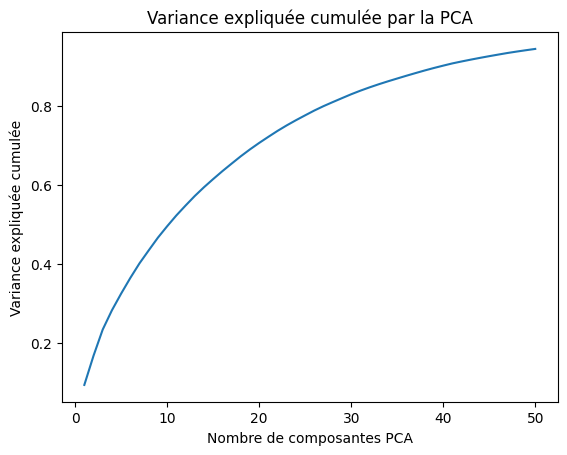

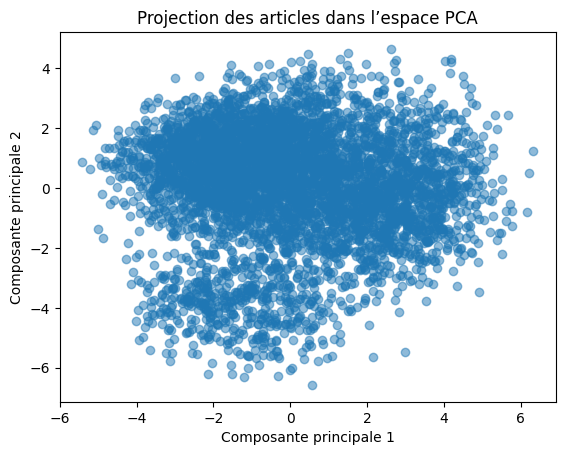

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Graphique 1 — Variance expliquée cumulée
# =========================
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel("Nombre de composantes PCA")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par la PCA")
plt.show()


# =========================
# Graphique 2 — Projection des articles (PCA 2D)
# =========================
# Sous-échantillonnage pour éviter un nuage trop dense
sample_size = 5000
idx = np.random.choice(X_reduced.shape[0], sample_size, replace=False)

plt.figure()
plt.scatter(X_reduced[idx, 0], X_reduced[idx, 1], alpha=0.5)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des articles dans l’espace PCA")
plt.show()


## Normalisation des embeddings PCA + reco PCA

In [29]:
# Normalisation L2 des embeddings réduits (pour cosine)
eps = 1e-12
X_pca = X_reduced.astype("float32")
X_pca = X_pca / np.maximum(np.linalg.norm(X_pca, axis=1, keepdims=True), eps)

def recommend_pca(user_id: int, k: int = 5, pool: int = 300):
    # Historique utilisateur (articles cliqués)
    hist = clicks.loc[clicks["user_id"] == user_id, "click_article_id"].astype(int).tolist()
    hist = [a for a in hist if 0 <= a < X_pca.shape[0]]

    # Cold start -> popularité
    if len(hist) == 0:
        return top_popular[:k]

    # Profil user = moyenne des embeddings (après PCA) des articles cliqués
    u = X_pca[hist].mean(axis=0)
    u = u / max(np.linalg.norm(u), eps)

    # Similarités cosine
    scores = X_pca @ u

    # Top candidats
    pool = min(pool, X_pca.shape[0] - 1)
    idx = np.argpartition(-scores, pool)[:pool]
    idx = idx[np.argsort(-scores[idx])]

    # Exclure déjà cliqués
    hist_set = set(hist)
    recs = []
    for i in idx:
        aid = int(i)
        if aid not in hist_set:
            recs.append(aid)
        if len(recs) == k:
            break

    # Compléter avec popularité si besoin
    if len(recs) < k:
        for aid in top_popular:
            if aid not in hist_set and aid not in recs:
                recs.append(aid)
            if len(recs) == k:
                break

    return recs

print("Reco PCA user 0:", recommend_pca(0))
print("Reco PCA user 1:", recommend_pca(1))
print("Reco PCA user 2:", recommend_pca(2))
print("Reco PCA user sans historique:", recommend_pca(999999))


Reco PCA user 0: [157519, 157944, 159495, 156690, 162857]
Reco PCA user 1: [95797, 90583, 236005, 231234, 37095]
Reco PCA user 2: [25856, 30693, 32503, 31139, 31325]
Reco PCA user sans historique: [119592, 96663, 108854, 284847, 235840]


### Comparaison avant/apres

In [30]:
print("Avant PCA user 0:", recommend(0))
print("Après PCA  user 0:", recommend_pca(0))


Avant PCA user 0: [157519, 162856, 159495, 157944, 156690]
Après PCA  user 0: [157519, 157944, 159495, 156690, 162857]


# Sauvegarde des embeddings PCA

In [31]:
import joblib
from pathlib import Path

OUT_PATH = Path("../data/articles_embeddings_pca50.joblib")
PCA_PATH = Path("../data/pca50.joblib")

joblib.dump(X_reduced.astype("float32"), OUT_PATH)
joblib.dump(pca, PCA_PATH)

print("✅ Sauvegardé :", OUT_PATH)
print("✅ Sauvegardé :", PCA_PATH)


✅ Sauvegardé : ..\data\articles_embeddings_pca50.joblib
✅ Sauvegardé : ..\data\pca50.joblib


# Synthèse du notebook d’exploration

**Objectif du notebook**

L’objectif de ce notebook était de poser les bases du système de recommandation d’articles dans une logique de MVP. La fonctionnalité cible consiste à proposer, pour un utilisateur donné, une sélection de **cinq articles pertinents**, à partir des interactions historiques disponibles.

---

**Données et contraintes identifiées**

L’exploration des données a mis en évidence plusieurs éléments structurants :

- un catalogue d’articles de grande taille ;
- un nombre limité d’utilisateurs ;
- un volume d’interactions relativement faible.

Ces caractéristiques conduisent à une **forte sparsité** des relations utilisateurs–articles, ce qui impose de privilégier des approches simples, robustes et capables de fonctionner avec peu d’informations par utilisateur.

---

**Stratégie de recommandation retenue**

Afin de répondre à ces contraintes, deux stratégies complémentaires ont été mises en place :

- **Recommandation par popularité**
  - utilisée comme baseline ;
  - sert de solution de repli pour les utilisateurs sans historique (*cold start*).

- **Recommandation basée sur le contenu**
  - s’appuie sur des embeddings d’articles ;
  - permet de personnaliser les recommandations lorsque des interactions passées sont disponibles.

---

**Représentation des articles par embeddings**

Les articles sont représentés par des embeddings vectoriels, dont les caractéristiques principales sont résumées ci-dessous :

| Élément | Valeur |
|-------|--------|
| Nombre d’articles représentés | 364 047 |
| Dimension initiale des embeddings | 250 |

La couverture des embeddings a été validée pour l’ensemble des articles cliqués. Après normalisation, ces représentations ont permis de calculer des similarités cosinus et de produire des recommandations différenciées selon les utilisateurs.

---

**Optimisation par réduction de dimension (PCA)**

Dans une perspective de déploiement serverless, une réduction de dimension par analyse en composantes principales (ACP / PCA) a été appliquée :

- réduction de **250 à 50 dimensions** ;
- **94 % de variance expliquée** conservée.

Les tests réalisés après cette étape montrent que le comportement global du système est préservé, avec des recommandations proches de celles obtenues avant compression.

---

**Conclusion**

Ce notebook a permis de valider la faisabilité d’un système de recommandation **simple, explicable et adapté aux contraintes d’un MVP**. Les choix méthodologiques effectués constituent une base solide pour la suite du projet, qui portera sur l’industrialisation de la logique de recommandation et son intégration dans une application de démonstration et une architecture serverless.
